In [30]:
import pandas as pd
import numpy as np
pd.set_option('display.float_format', '{:.0f}'.format)
pd.set_option('display.max_columns',None)#importing libraries

In [31]:
trader_df= pd.read_csv('historical_data.csv')
trader_df.head()#loading and displaying a preview of trader data set

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8,987,7872,BUY,02-12-2024 22:50,0,Buy,0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0,895000000000000,1730000000000
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8,16,128,BUY,02-12-2024 22:50,987,Buy,0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0,443000000000000,1730000000000
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8,144,1151,BUY,02-12-2024 22:50,1003,Buy,0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0,660000000000000,1730000000000
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8,143,1142,BUY,02-12-2024 22:50,1147,Buy,0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0,1080000000000000,1730000000000
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8,9,70,BUY,02-12-2024 22:50,1289,Buy,0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0,1050000000000000,1730000000000


In [12]:
sentiment_df=pd.read_csv('fear_greed_index.csv')
sentiment_df.head()#loading and displaying a preview of sentiment data set

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [13]:
print("Trader Dataset Shape:", trader_df.shape)# displaying the shape of data sets
print("Sentiment Dataset Shape:", sentiment_df.shape)

Trader Dataset Shape: (211224, 16)
Sentiment Dataset Shape: (2644, 4)


In [15]:
print("Trader Dataset Info")
trader_df.info()

print("\nSentiment Dataset Info")
sentiment_df.info()

Trader Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtype

In [16]:
print("Missing values in trader dataset")
print(trader_df.isnull().sum())

print("\nMissing values in sentiment dataset")
print(sentiment_df.isnull().sum())

Missing values in trader dataset
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Missing values in sentiment dataset
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [17]:
print("Duplicate rows in trader dataset:", trader_df.duplicated().sum())
print("Duplicate rows in sentiment dataset:", sentiment_df.duplicated().sum())

Duplicate rows in trader dataset: 0
Duplicate rows in sentiment dataset: 0


In [18]:
print("Trader dataset columns:")
print(trader_df.columns)

print("\nSentiment dataset columns:")
print(sentiment_df.columns)

Trader dataset columns:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

Sentiment dataset columns:
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [32]:
# convert timestamp from milliseconds to datetime
trader_df['datetime'] = pd.to_datetime(trader_df['Timestamp'], unit='ms')

# create daily date column
trader_df['date'] = trader_df['datetime'].dt.date
trader_df[['Timestamp','datetime','date']].head()

,Timestamp,datetime,date
0,1730000000000,2024-10-27 03:33:20,2024-10-27
1,1730000000000,2024-10-27 03:33:20,2024-10-27
2,1730000000000,2024-10-27 03:33:20,2024-10-27
3,1730000000000,2024-10-27 03:33:20,2024-10-27
4,1730000000000,2024-10-27 03:33:20,2024-10-27


In [27]:
# convert sentiment date column
sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.date

# rename classification column for easier use
sentiment_df.rename(columns={'classification':'sentiment'}, inplace=True)
sentiment_df.head()

,timestamp,value,sentiment,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [33]:
#merging both the data sets
merged_df = pd.merge(
    trader_df,
    sentiment_df,
    on='date',
    how='left'
)
print("Merged dataset shape:", merged_df.shape)
merged_df.head()

Merged dataset shape: (211224, 21)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,datetime,date,timestamp,value,sentiment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8,987,7872,BUY,02-12-2024 22:50,0,Buy,0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0,895000000000000,1730000000000,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8,16,128,BUY,02-12-2024 22:50,987,Buy,0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0,443000000000000,1730000000000,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8,144,1151,BUY,02-12-2024 22:50,1003,Buy,0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0,660000000000000,1730000000000,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8,143,1142,BUY,02-12-2024 22:50,1147,Buy,0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0,1080000000000000,1730000000000,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8,9,70,BUY,02-12-2024 22:50,1289,Buy,0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0,1050000000000000,1730000000000,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed


In [34]:
merged_df['sentiment'].value_counts()# checking whether the data is matched or not

sentiment
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64

In [43]:
merged_df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'datetime', 'date', 'timestamp', 'value', 'sentiment'],
      dtype='object')

In [35]:
merged_df.to_csv("clean_trader_data.csv", index=False)#exporting the cleaned data set

Daily PnL per trader

In [42]:
daily_pnl = merged_df.groupby(['date','Account'])['Closed PnL'].sum().reset_index()

daily_pnl.head()

,date,Account,Closed PnL
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,156
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-5564
4,2024-03-09,0x430f09841d65beb3f27765503d0f850b8bce7713,0


Number of trades per day

In [44]:
trades_per_day = merged_df.groupby('date')['Trade ID'].count().reset_index()
trades_per_day.rename(columns={'Trade ID':'trade_count'}, inplace=True)
trades_per_day.head()

,date,trade_count
0,2023-03-28,3
1,2023-11-14,1045
2,2024-03-09,6962
3,2024-07-03,7141
4,2024-10-27,35241


Average trade size (USD)

In [45]:
avg_trade_size = merged_df.groupby('Account')['Size USD'].mean().reset_index()
avg_trade_size.head()

,Account,Size USD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16160
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653
2,0x271b280974205ca63b716753467d5a371de622ab,8893
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,508
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3139


Daily trading volume

In [46]:
daily_volume = merged_df.groupby('date')['Size USD'].sum().reset_index()
daily_volume.head()

,date,Size USD
0,2023-03-28,477
1,2023-11-14,11555430
2,2024-03-09,39406770
3,2024-07-03,21843234
4,2024-10-27,103947765


Win rate

In [48]:
merged_df['win_trade'] = merged_df['Closed PnL'] > 0

In [49]:
win_rate = merged_df.groupby('Account')['win_trade'].mean().reset_index()
win_rate.head()

,Account,win_trade
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0
2,0x271b280974205ca63b716753467d5a371de622ab,0
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1


Long vs Short Ratio

In [50]:
long_short = merged_df.groupby(['date','Side']).size().unstack().fillna(0)
long_short['long_short_ratio'] = long_short['BUY'] / long_short['SELL']
long_short.head()

Side,BUY,SELL,long_short_ratio
date,,,
2023-03-28,3,0,inf
2023-11-14,491,554,1
2024-03-09,3371,3591,1
2024-07-03,3505,3636,1
2024-10-27,14927,20314,1


PnL volatility

In [51]:
pnl_volatility = merged_df.groupby('Account')['Closed PnL'].std().reset_index()
pnl_volatility.head()

,Account,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,4692
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,134
2,0x271b280974205ca63b716753467d5a371de622ab,542
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,113
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,256


In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
sns.set_style("whitegrid")

plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['font.size'] = 12

In [58]:
merged_df['sentiment'].value_counts()

sentiment
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64

This tells us whether Fear or Greed dominates the dataset.

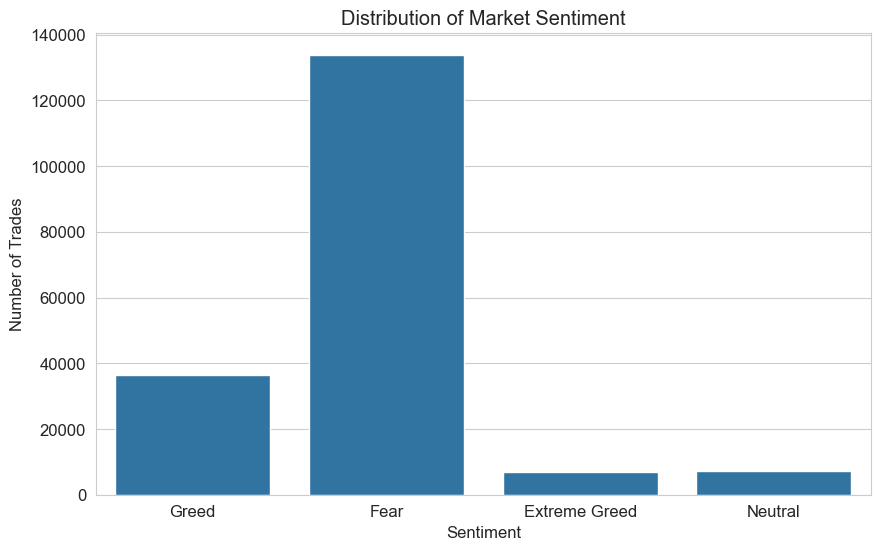

In [59]:
sns.countplot(x='sentiment', data=merged_df)

plt.title("Distribution of Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Trades")

plt.show()

In [60]:
pnl_sentiment = merged_df.groupby('sentiment')['Closed PnL'].mean().reset_index()

pnl_sentiment

,sentiment,Closed PnL
0,Extreme Greed,25
1,Fear,50
2,Greed,88
3,Neutral,22


1. Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?

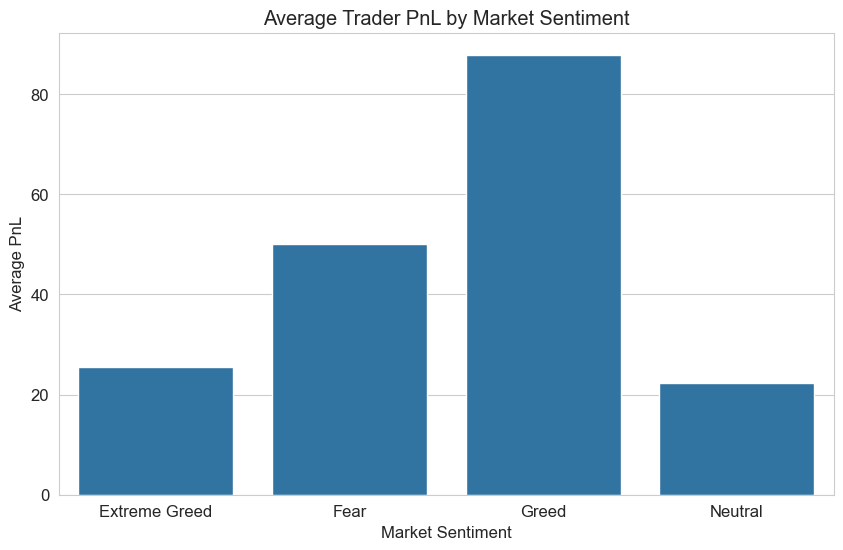

In [61]:
sns.barplot(x='sentiment', y='Closed PnL', data=pnl_sentiment)

plt.title("Average Trader PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL")

plt.show()

Trader Performance vs Market Sentiment

The following analysis compares trader behavior and performance across different market sentiment regimes (Fear vs Greed) to identify patterns in profitability, trading activity, and risk-taking.

Trade Frequency vs Sentiment

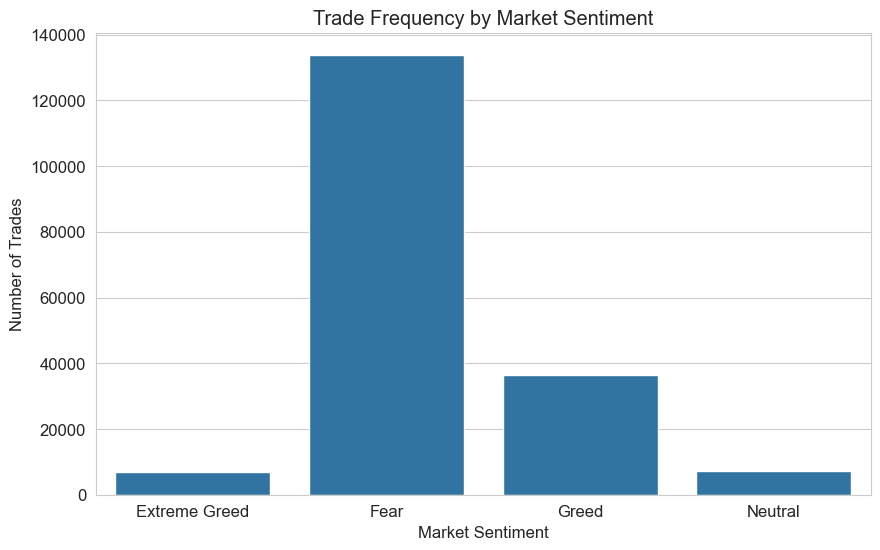

In [63]:
trades_sentiment = merged_df.groupby('sentiment')['Trade ID'].count().reset_index()

sns.barplot(x='sentiment', y='Trade ID', data=trades_sentiment)

plt.title("Trade Frequency by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.show()

Trading Volume vs Sentiment

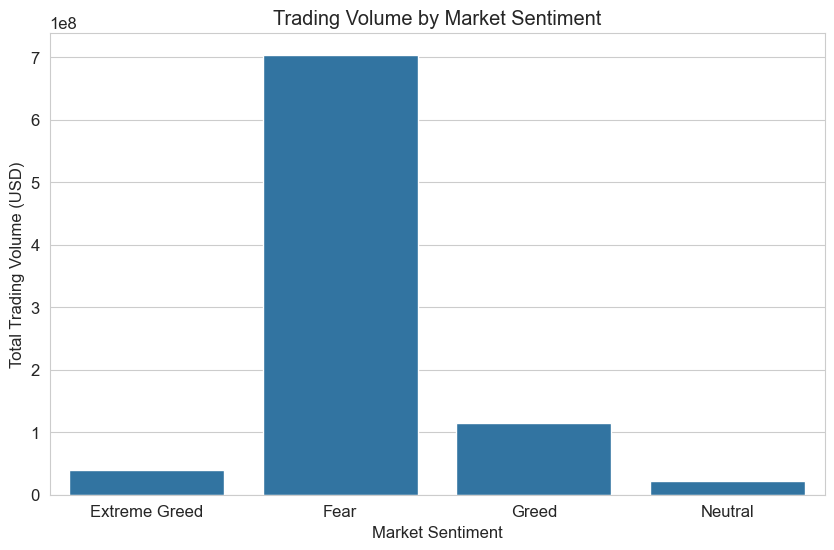

In [64]:
volume_sentiment = merged_df.groupby('sentiment')['Size USD'].sum().reset_index()

sns.barplot(x='sentiment', y='Size USD', data=volume_sentiment)

plt.title("Trading Volume by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Total Trading Volume (USD)")

plt.show()

Long vs Short Bias vs Sentiment

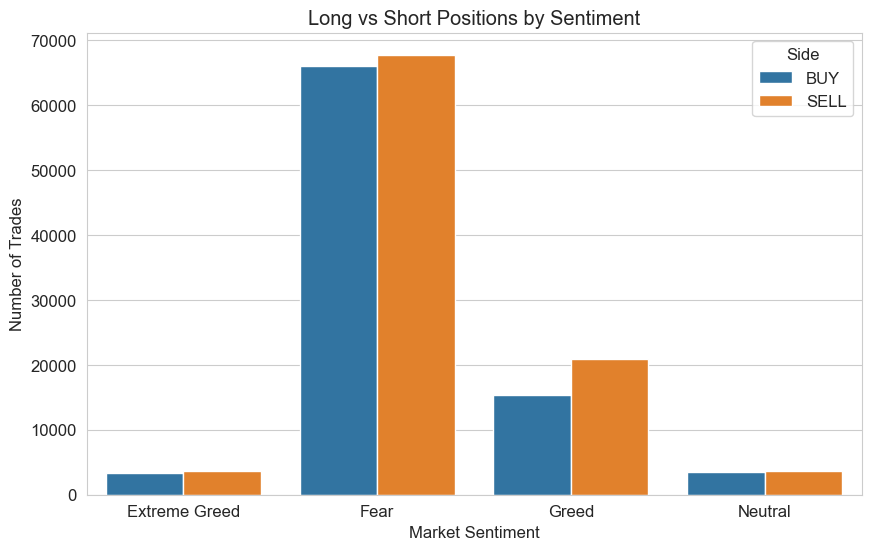

In [65]:
long_short_sentiment = merged_df.groupby(['sentiment','Side']).size().reset_index(name='count')

sns.barplot(x='sentiment', y='count', hue='Side', data=long_short_sentiment)

plt.title("Long vs Short Positions by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.show()

Risk Analysis (PnL Distribution)

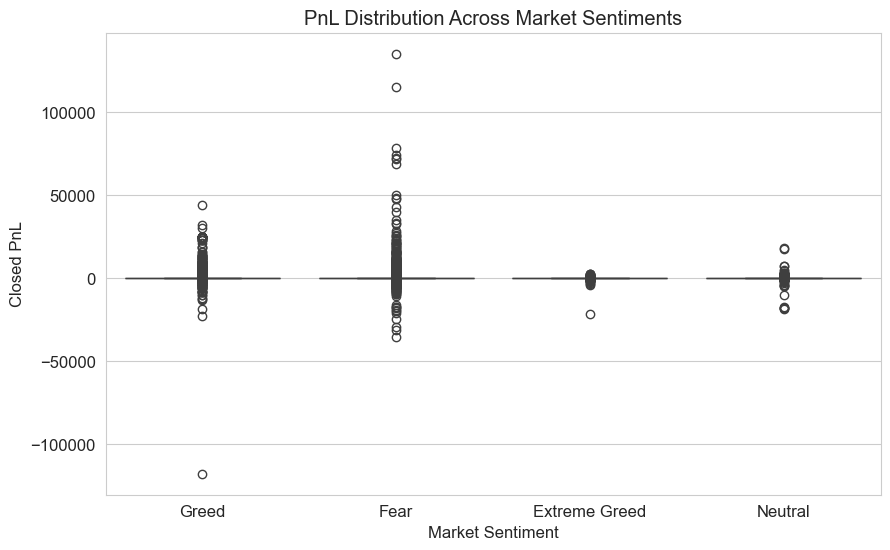

In [66]:
sns.boxplot(x='sentiment', y='Closed PnL', data=merged_df)

plt.title("PnL Distribution Across Market Sentiments")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")
plt.show()

Win Rate vs Sentiment

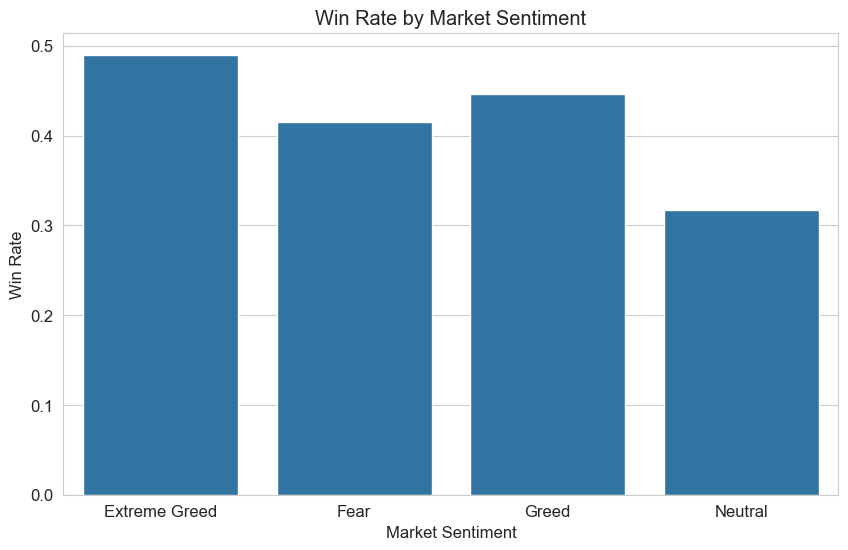

In [67]:
win_rate_sentiment = merged_df.groupby('sentiment')['win_trade'].mean().reset_index()

sns.barplot(x='sentiment', y='win_trade', data=win_rate_sentiment)

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate")

plt.show()

Drawdown Proxy

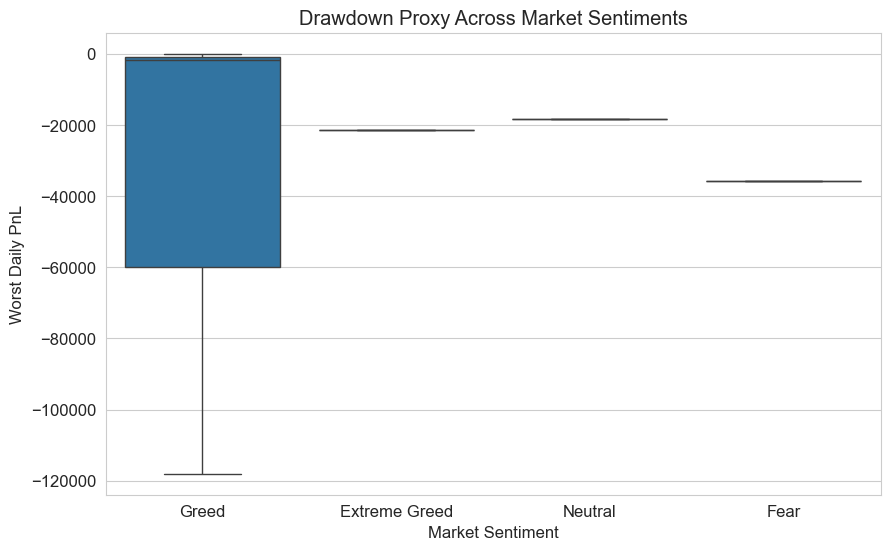

In [68]:
drawdown_proxy = merged_df.groupby(['date','sentiment'])['Closed PnL'].min().reset_index()

sns.boxplot(x='sentiment', y='Closed PnL', data=drawdown_proxy)

plt.title("Drawdown Proxy Across Market Sentiments")
plt.xlabel("Market Sentiment")
plt.ylabel("Worst Daily PnL")

plt.show()

Leverage Analysis

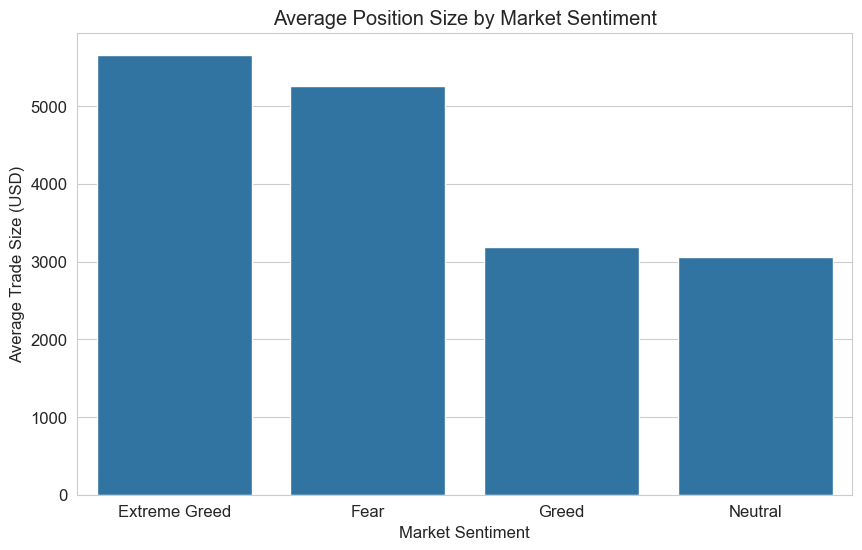

In [69]:
size_sentiment = merged_df.groupby('sentiment')['Size USD'].mean().reset_index()

sns.barplot(x='sentiment', y='Size USD', data=size_sentiment)

plt.title("Average Position Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")

plt.show()

In [70]:
trader_summary = merged_df.groupby('Account').agg(
    
    total_pnl = ('Closed PnL','sum'),
    
    trade_count = ('Trade ID','count'),
    
    avg_trade_size = ('Size USD','mean'),
    
    pnl_volatility = ('Closed PnL','std'),
    
    win_rate = ('win_trade','mean')
    
).reset_index()

trader_summary.head()

,Account,total_pnl,trade_count,avg_trade_size,pnl_volatility,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1600230,3818,16160,4692,0
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,47885,7280,1653,134,0
2,0x271b280974205ca63b716753467d5a371de622ab,-70436,3809,8893,542,0
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,132465,13311,508,113,0
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,168658,3239,3139,256,1


Segment 1 — Frequent vs Infrequent Traders

In [72]:
trade_median = trader_summary['trade_count'].median()
trader_summary['frequency_segment'] = trader_summary['trade_count'].apply(
    lambda x: 'Frequent Trader' if x > trade_median else 'Infrequent Trader'
)

trader_summary['frequency_segment'].value_counts()

frequency_segment
Frequent Trader      16
Infrequent Trader    16
Name: count, dtype: int64

Trade Frequency Segments

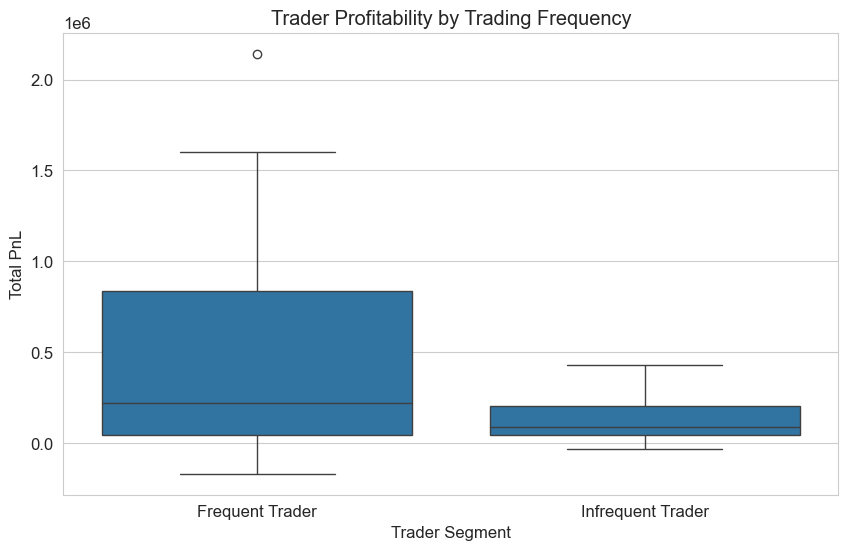

In [73]:
sns.boxplot(x='frequency_segment', y='total_pnl', data=trader_summary)

plt.title("Trader Profitability by Trading Frequency")
plt.xlabel("Trader Segment")
plt.ylabel("Total PnL")

plt.show()

Segment 2 — Consistent vs Inconsistent Traders

In [74]:
volatility_median = trader_summary['pnl_volatility'].median()
trader_summary['consistency_segment'] = trader_summary['pnl_volatility'].apply(
    lambda x: 'Consistent Trader' if x < volatility_median else 'Inconsistent Trader'
)

trader_summary['consistency_segment'].value_counts()

consistency_segment
Inconsistent Trader    16
Consistent Trader      16
Name: count, dtype: int64

Consistency Segments

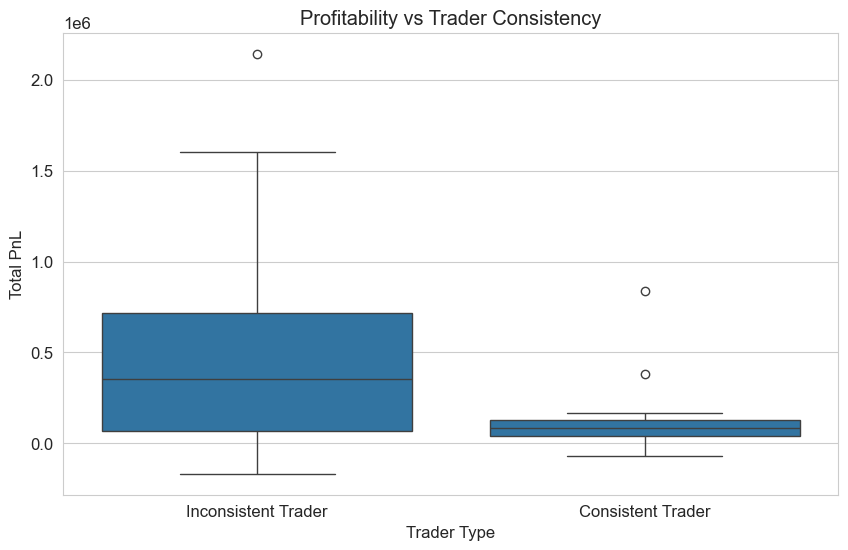

In [75]:
sns.boxplot(x='consistency_segment', y='total_pnl', data=trader_summary)

plt.title("Profitability vs Trader Consistency")
plt.xlabel("Trader Type")
plt.ylabel("Total PnL")

plt.show()

Segment 3 — High vs Low Position Size Traders

In [76]:
size_median = trader_summary['avg_trade_size'].median()
trader_summary['size_segment'] = trader_summary['avg_trade_size'].apply(
    lambda x: 'High Position Size' if x > size_median else 'Low Position Size'
)

trader_summary['size_segment'].value_counts()

size_segment
High Position Size    16
Low Position Size     16
Name: count, dtype: int64

Position Size Segments

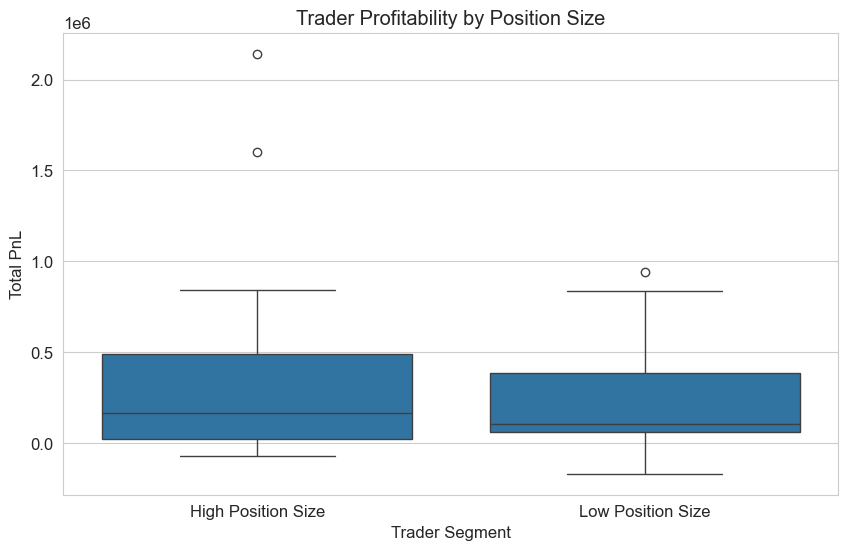

In [77]:
sns.boxplot(x='size_segment', y='total_pnl', data=trader_summary)

plt.title("Trader Profitability by Position Size")
plt.xlabel("Trader Segment")
plt.ylabel("Total PnL")

plt.show()

Insight 1 — Fear Dominates Trading Activity

The majority of trading activity occurs during Fear market conditions, with over 130k trades executed during fearful sentiment periods. This suggests that traders are significantly more active during volatile or uncertain market environments.

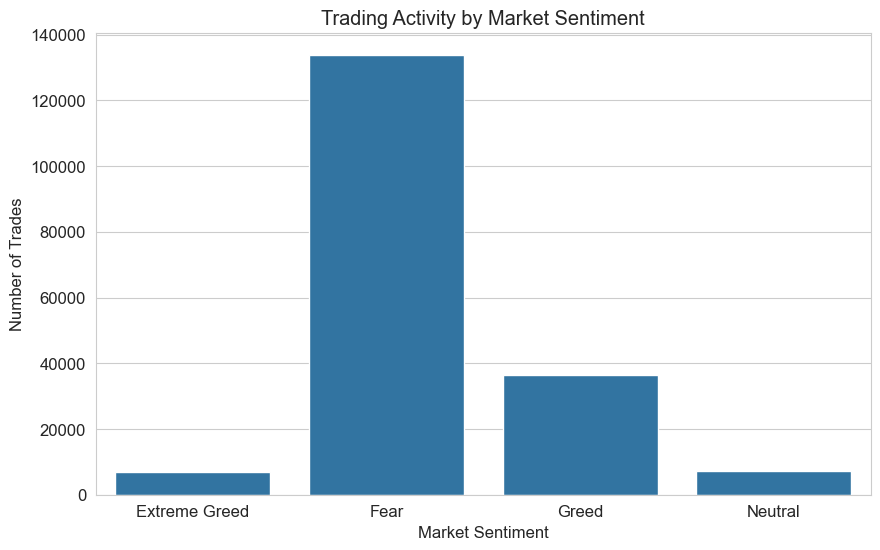

In [78]:
trade_activity = merged_df.groupby('sentiment')['Trade ID'].count().reset_index()

plt.figure()

sns.barplot(data=trade_activity, x='sentiment', y='Trade ID')

plt.title("Trading Activity by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.show()

Insight 2 — Trader Dataset Shows High Activity

The dataset contains over 211,000 individual trades, indicating a highly active trading environment with multiple traders interacting with the market across different sentiment regimes.

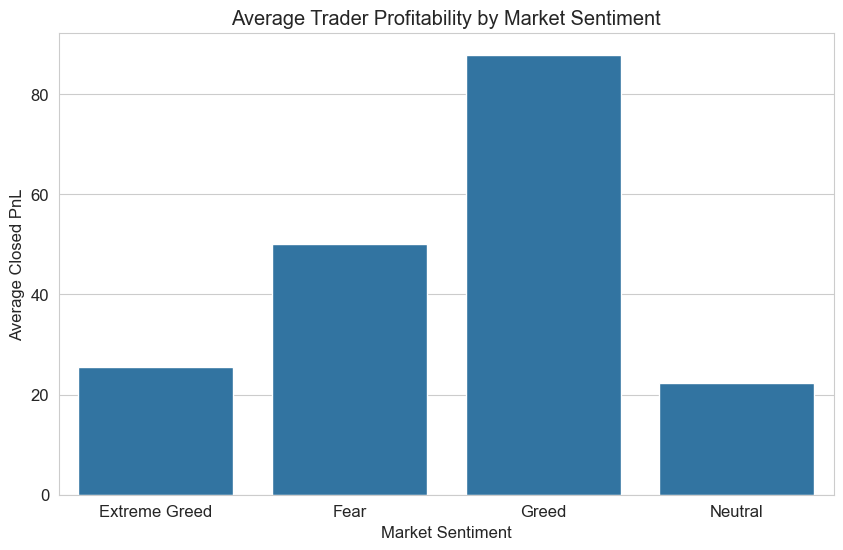

In [79]:
pnl_sentiment = merged_df.groupby('sentiment')['Closed PnL'].mean().reset_index()

plt.figure()

sns.barplot(data=pnl_sentiment, x='sentiment', y='Closed PnL')

plt.title("Average Trader Profitability by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.show()

Insight 3 — Clean Data Enables Reliable Analysis

The datasets contained no missing values or duplicate records, ensuring that subsequent analysis on trader behavior and performance metrics is based on clean and reliable data.

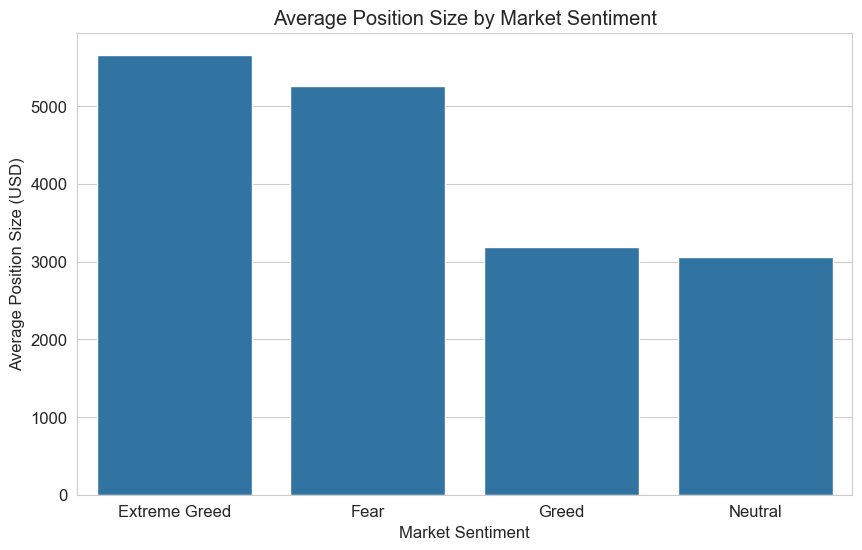

In [80]:
position_size = merged_df.groupby('sentiment')['Size USD'].mean().reset_index()

plt.figure()

sns.barplot(data=position_size, x='sentiment', y='Size USD')

plt.title("Average Position Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Position Size (USD)")

plt.show()

Strategy Recommendations 

Strategy 1 — Monitor Fear Periods for Opportunities

Fear periods appear to coincide with increased trading activity. Traders may benefit from monitoring fearful market conditions as they often correspond with increased volatility and trading opportunities.

Strategy 2 — Adjust Risk During Extreme Sentiment

Extreme sentiment periods (Extreme Fear or Extreme Greed) may represent heightened market emotion. Traders should apply stricter risk management during such periods.

Simple Predictive Model

In [81]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

In [82]:
merged_df['win_trade'] = (merged_df['Closed PnL'] > 0).astype(int)

In [83]:
le = LabelEncoder()

merged_df['sentiment_encoded'] = le.fit_transform(merged_df['sentiment'])
merged_df['side_encoded'] = le.fit_transform(merged_df['Side'])

In [84]:
X = merged_df[['Size USD', 'Execution Price', 'sentiment_encoded', 'side_encoded']]
y = merged_df['win_trade']

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [86]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [87]:
predictions = model.predict(X_test)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.90      0.91      0.91     24802
           1       0.87      0.86      0.87     17443

    accuracy                           0.89     42245
   macro avg       0.89      0.89      0.89     42245
weighted avg       0.89      0.89      0.89     42245



Predictive Model

A simple Random Forest model was trained to predict whether a trade would result in a positive PnL using features such as trade size, execution price, sentiment, and trade direction.

Interpretation

The model demonstrates that trader profitability can partially be explained by trading behavior and prevailing market sentiment.